
# K-means on the Iris dataset: how the choice of K changes the result

This notebook supports the tutorial document. It uses **Iris.csv** and focuses on a practical question: **how should we choose K in K-means?**

Workflow:
1. Load and inspect the dataset.
2. Remove `Id` and hold out `Species` during fitting.
3. Standardise the four numeric features.
4. Compare candidate values of K using inertia, silhouette score and the Davies-Bouldin index.
5. Visualise how the partition changes for **K = 2, 3 and 5**.
6. Interpret the **K = 3** centroids as feature profiles.

References used in preparation: MacQueen (1967), Lloyd (1982), Arthur and Vassilvitskii (2007), Rousseeuw (1987), Davies and Bouldin (1979), Fisher (1936), and the scikit-learn documentation.


GitHub Link : https://github.com/bilalahmadcheema37-a11y/kmeans-clustering-tutorial/tree/main


In [13]:

    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    from sklearn.decomposition import PCA

    # 1. Load dataset
    data = pd.read_csv('Iris.csv')
    print('Shape:', data.shape)
    print('Columns:', list(data.columns))
    print('First five rows:')
    display(data.head())

    print('Missing values per column:')
    print(data.isna().sum())


Shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
First five rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [5]:

# 2. Prepare features for clustering
# 'Species' is kept only for post-hoc interpretation, not for fitting.
X = data.drop(columns=['Id', 'Species'])
species = data['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features used for clustering:')
display(X.head())


Features used for clustering:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:

# 3. Evaluate K from 2 to 7
k_values = range(2, 8)
inertia_values = []
silhouette_values = []
db_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))
    db_values.append(davies_bouldin_score(X_scaled, labels))

metrics = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_values,
    'Silhouette': silhouette_values,
    'Davies-Bouldin': db_values,
})
display(metrics)


C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

,K,Inertia,Silhouette,Davies-Bouldin
0,2,223.732006,0.580184,0.597555
1,3,140.965817,0.458972,0.835410
2,4,114.617886,0.385285,0.872729
3,5,91.295445,0.347265,0.940632
4,6,81.756582,0.340650,1.007727
5,7,71.319821,0.328832,0.993932


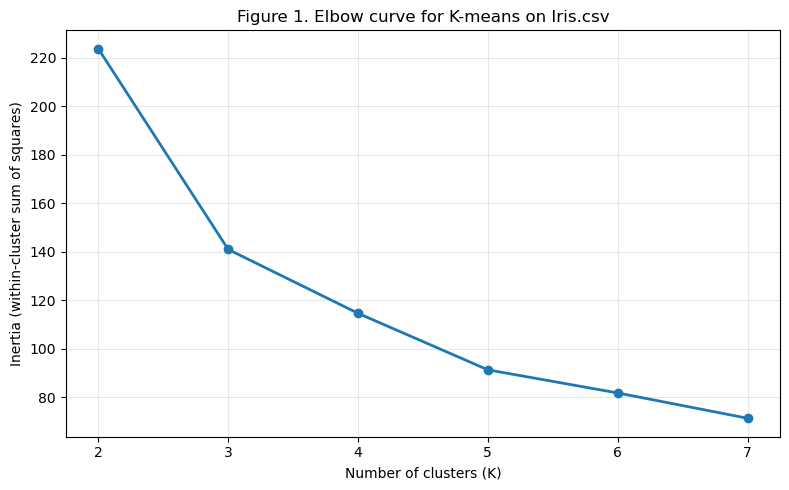

In [7]:

# Figure 1: elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o', linewidth=2)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Figure 1. Elbow curve for K-means on Iris.csv')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_1_elbow.png', dpi=300)
plt.show()


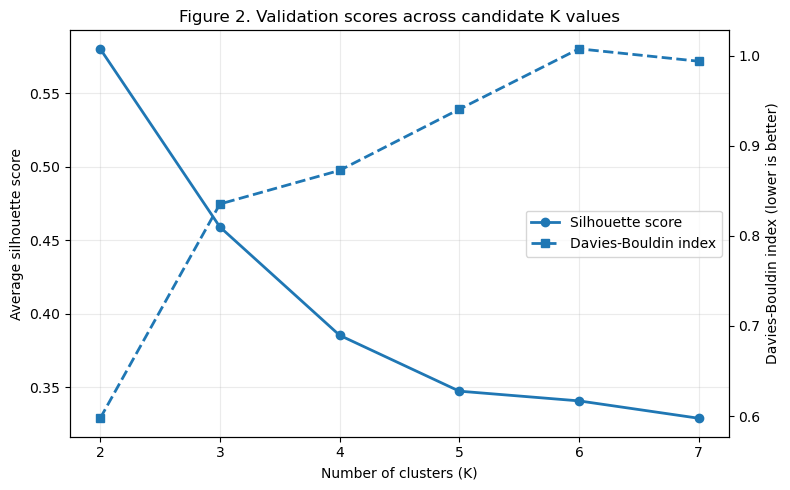

In [8]:

# Figure 2: silhouette and Davies-Bouldin together
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_values), silhouette_values, marker='o', linewidth=2, label='Silhouette score')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Average silhouette score')
ax1.set_xticks(list(k_values))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(list(k_values), db_values, marker='s', linestyle='--', linewidth=2, label='Davies-Bouldin index')
ax2.set_ylabel('Davies-Bouldin index (lower is better)')

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='center right')
plt.title('Figure 2. Validation scores across candidate K values')
plt.tight_layout()
plt.savefig('figure_2_validation.png', dpi=300)
plt.show()


C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


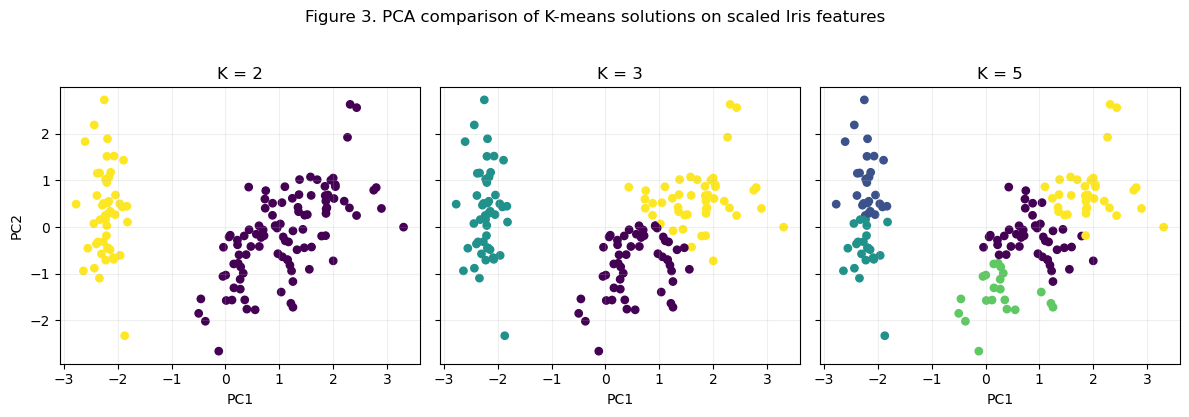

In [9]:

# Figure 3: compare K = 2, 3 and 5 in PCA space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, k in zip(axes, [2, 3, 5]):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=28)
    ax.set_title(f'K = {k}')
    ax.set_xlabel('PC1')
    if ax is axes[0]:
        ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.2)

fig.suptitle('Figure 3. PCA comparison of K-means solutions on scaled Iris features', y=1.03)
plt.tight_layout()
plt.savefig('figure_3_pca_compare.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Bilu Plumber\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Cluster 0,-0.050220,-0.880292,0.347532,0.282063
Cluster 1,-1.014579,0.842307,-1.304878,-1.255129
Cluster 2,1.135970,0.096598,0.996271,1.017172


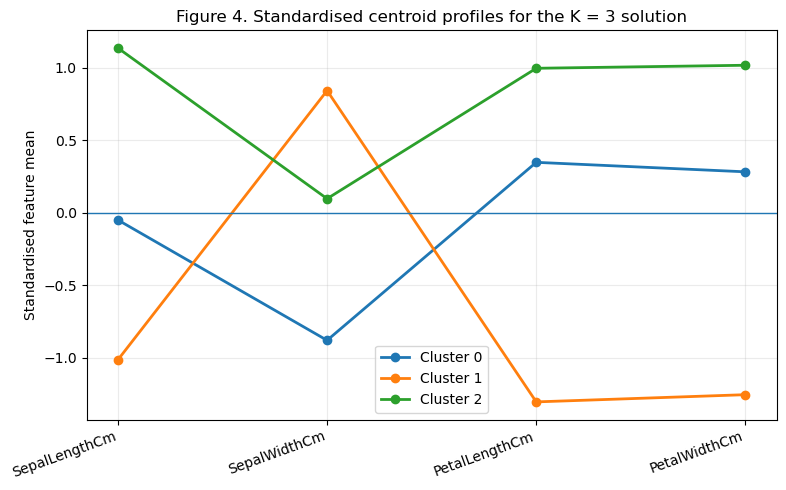

In [10]:

# Figure 4: centroid profiles for K = 3
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(X_scaled)
data['Cluster'] = cluster_labels

centroids = pd.DataFrame(
    final_model.cluster_centers_,
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(3)]
)
display(centroids)

plt.figure(figsize=(8, 5))
for idx, row in centroids.iterrows():
    plt.plot(X.columns, row.values, marker='o', linewidth=2, label=idx)
plt.axhline(0, linewidth=1)
plt.ylabel('Standardised feature mean')
plt.title('Figure 4. Standardised centroid profiles for the K = 3 solution')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('figure_4_centroids.png', dpi=300)
plt.show()


In [12]:

    print('Post-hoc cross-tabulation against held-out species labels:')
    print(pd.crosstab(data['Cluster'], species))

    print('Interpretation note:')
    print('The validation metrics favour K = 2 because Iris-setosa is very distinct,')
    print('while the two remaining species overlap more strongly. K = 3 is still a')
    print('useful teaching choice because it reveals the finer-grained structure and')
    print('matches the known three-species composition of the dataset without using')
    print('those labels during fitting.')


Post-hoc cross-tabulation against held-out species labels:
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               39              14
1                 50                0               0
2                  0               11              36
Interpretation note:
The validation metrics favour K = 2 because Iris-setosa is very distinct,
while the two remaining species overlap more strongly. K = 3 is still a
useful teaching choice because it reveals the finer-grained structure and
matches the known three-species composition of the dataset without using
those labels during fitting.
